# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report # to check the score of both models
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle



In [84]:
df = pd.read_csv("data/data.csv")

In [85]:
df.head()

,Number_of_Customers,Menu_Price,Marketing_Spend,Cuisine_Type,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
0,61,43.117635,12.663793,Japanese,36.236133,0,45,350.912040
1,24,40.020077,4.577892,Italian,17.952562,0,36,221.319091
2,81,41.981485,4.652911,Japanese,22.600420,1,91,326.529763
3,70,43.005307,4.416053,Italian,18.984098,1,59,348.190573
4,30,17.456199,3.475052,Italian,12.766143,1,30,185.009121


In [86]:
df.isnull().sum()

Number_of_Customers          0
Menu_Price                   0
Marketing_Spend              0
Cuisine_Type                 0
Average_Customer_Spending    0
Promotions                   0
Reviews                      0
Monthly_Revenue              0
dtype: int64

In [87]:
df.describe()

,Number_of_Customers,Menu_Price,Marketing_Spend,Average_Customer_Spending,Promotions,Reviews,Monthly_Revenue
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,53.271000,30.219120,9.958726,29.477085,0.497000,49.837000,268.724172
std,26.364914,11.278760,5.845586,11.471686,0.500241,29.226334,103.982950
min,10.000000,10.009501,0.003768,10.037177,0.000000,0.000000,-28.977809
25%,30.000000,20.396828,4.690724,19.603041,0.000000,24.000000,197.103642
50%,54.000000,30.860614,10.092047,29.251365,0.000000,50.000000,270.213964
75%,74.000000,39.843868,14.992436,39.553220,1.000000,76.000000,343.395793
max,99.000000,49.974140,19.994276,49.900725,1.000000,99.000000,563.381332


In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Cuisine_Type               1000 non-null   object 
 4   Average_Customer_Spending  1000 non-null   float64
 5   Promotions                 1000 non-null   int64  
 6   Reviews                    1000 non-null   int64  
 7   Monthly_Revenue            1000 non-null   float64
dtypes: float64(4), int64(3), object(1)
memory usage: 62.6+ KB


In [89]:
df.duplicated().sum()

np.int64(0)

# Cleaning of data is not needed,there is no any column which can confuse the model and also there is no null sections

# Encoding the data

In [90]:
ohe_column = [column for column in df.columns if df[column].dtype == 'object'] # created the list of column of type object
df=pd.get_dummies(df, columns=ohe_column, drop_first=True)

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Number_of_Customers        1000 non-null   int64  
 1   Menu_Price                 1000 non-null   float64
 2   Marketing_Spend            1000 non-null   float64
 3   Average_Customer_Spending  1000 non-null   float64
 4   Promotions                 1000 non-null   int64  
 5   Reviews                    1000 non-null   int64  
 6   Monthly_Revenue            1000 non-null   float64
 7   Cuisine_Type_Italian       1000 non-null   bool   
 8   Cuisine_Type_Japanese      1000 non-null   bool   
 9   Cuisine_Type_Mexican       1000 non-null   bool   
dtypes: bool(3), float64(4), int64(3)
memory usage: 57.7 KB


# Splitting the data in train and to test to train model
### *Here i will use 20% data to test and 80% to train*

In [92]:
target_col = 'Reviews' # change if file has different column name
y = df[target_col]
X = df.drop(columns=[target_col])

In [93]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

eda

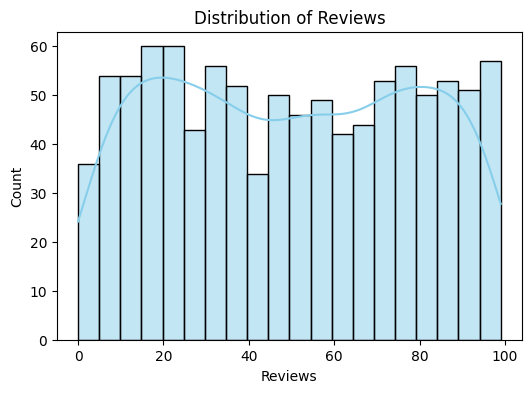

In [94]:
plt.figure(figsize=(6,4))
sns.histplot(df[target_col], kde=True, bins=20, color="skyblue")
plt.title(f"Distribution of {target_col}")
plt.show()

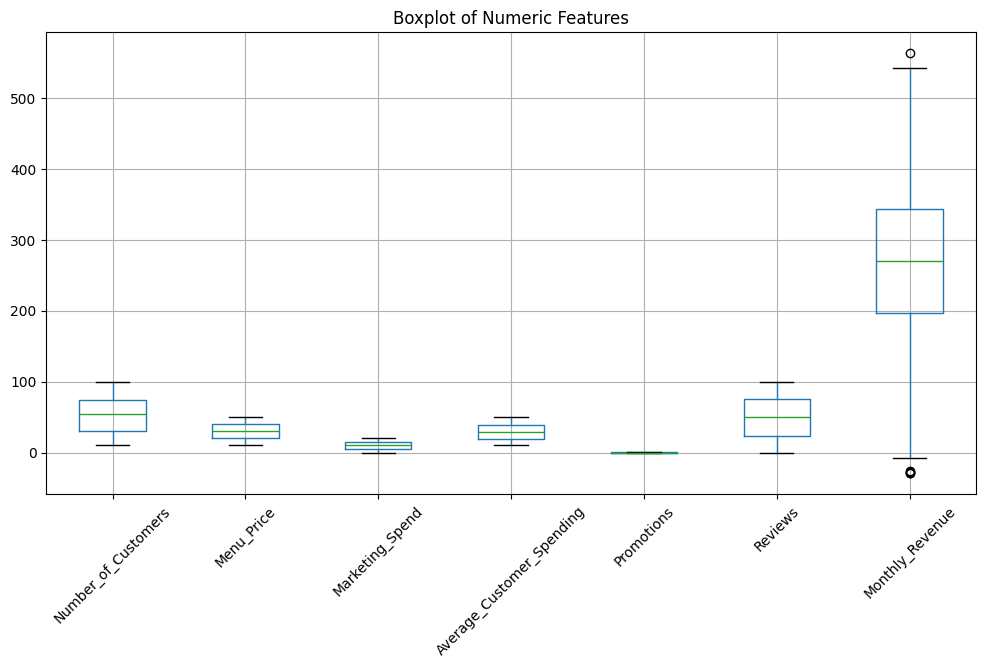

In [95]:
# 3.3 Boxplots for detecting outliers (numeric columns)
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(12,6))
df[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot of Numeric Features")
plt.show()

# Modeling

# Initialising model 1

# Logistic Regression Score
print("Logistic Regression Accuracy:", accuracy_score(y_test, log_model.predict(X_test)))
print(confusion_matrix(y_test, log_model.predict(X_test)))
print(classification_report(y_test, log_model.predict(X_test)))

# Initialising model 2

In [96]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [97]:
# Random Forest Score
print("Random Forest Accuracy:", accuracy_score(y_test, rf.predict(X_test)))
print(confusion_matrix(y_test, rf.predict(X_test)))
print(classification_report(y_test, rf.predict(X_test)))

ValueError: Classification metrics can't handle a mix of multiclass and continuous targets